# Week 7 Lab — SOLUTIONS — ARCH and GARCH Models

**MANG2074 Financial Econometrics 1**

**Objectives**

- Document volatility clustering and fat tails in daily FX and equity returns.
- Test for ARCH effects with the ARCH-LM test.
- Estimate ARCH(q) and GARCH(1,1) by maximum likelihood with the `arch` package.
- Interpret $\alpha$, $\beta$, persistence and the unconditional variance.

**Data**

- `../data/currencies.csv` — daily `EUR`, `GBP`, `JPY` dollar exchange rates, 1998–2018.
- `../data/sp500.csv` — daily S&P 500 index, 1950–2018.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

fx = pd.read_csv('../data/currencies.csv', index_col=0, parse_dates=True)
fx['rjpy'] = 100 * np.log(fx['JPY']).diff()
rjpy = fx['rjpy'].dropna()

sp = pd.read_csv('../data/sp500.csv', index_col=0, parse_dates=True)
rsp = (100 * np.log(sp['sp500']).diff()).dropna()
print(rjpy.describe().round(3))

count    7141.000
mean       -0.001
std         0.471
min        -3.664
25%        -0.208
50%         0.000
75%         0.206
max         2.850
Name: rjpy, dtype: float64


## Task 1 — Stylised facts

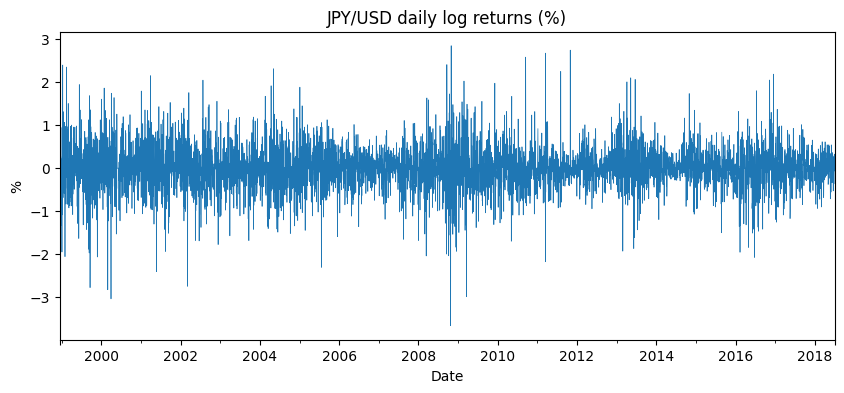

rjpy: skew = -0.133, excess kurtosis = 4.639
S&P500: skew = -1.017, excess kurtosis = 27.183


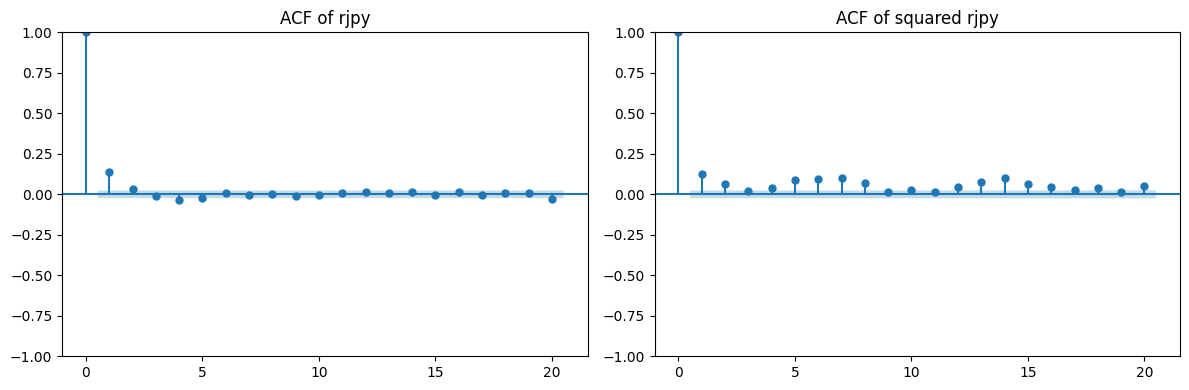

In [2]:
# (a) time-series plot
plt.figure(figsize=(10, 4))
rjpy.plot(lw=0.5)
plt.title('JPY/USD daily log returns (%)'); plt.ylabel('%'); plt.show()

# (b) moments
for r, name in [(rjpy, 'rjpy'), (rsp, 'S&P500')]:
    print(f"{name}: skew = {r.skew():.3f}, excess kurtosis = {r.kurtosis():.3f}")

# (c) ACFs of returns and squared returns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(rjpy, lags=20, ax=axes[0], title='ACF of rjpy')
plot_acf(rjpy**2, lags=20, ax=axes[1], title='ACF of squared rjpy')
plt.tight_layout(); plt.show()


**What to interpret.** (a) Clear clustering: turbulence in 1998 (LTCM/yen carry unwind), 2008–09, and 2016, separated by calm stretches. (b) Both series are leptokurtic (excess kurtosis ≈ 4.6 for the yen, far higher for the S&P). (c) The killer pair of plots: returns themselves are almost serially uncorrelated (left — consistent with market efficiency), but **squared** returns are positively autocorrelated at every lag (right). The *level* is unpredictable; the *risk* is predictable. That is precisely the structure ARCH/GARCH models exploit.

## Task 2 — ARCH-LM test

In [3]:
for r, name in [(rjpy, 'rjpy'), (rsp, 'S&P500')]:
    lm, lm_p, f, f_p = het_arch(r - r.mean(), nlags=5)
    print(f"{name}: ARCH-LM(5) = {lm:.1f}, p-value = {lm_p:.3g}")


rjpy: ARCH-LM(5) = 178.8, p-value = 9.65e-37
S&P500: ARCH-LM(5) = 1447.8, p-value = 6.04e-311


**What to interpret.** $H_0$: no ARCH effects (squared shocks unpredictable from their own past); LM $\sim \chi^2(5)$ under $H_0$. Both p-values are essentially zero — overwhelming ARCH effects in both series. Running this first matters because if the test did *not* reject, a GARCH model would be unidentified noise-fitting; it also tells us a constant-variance OLS model of these returns would have invalid standard errors.

## Task 3 — Estimate ARCH(5)

In [4]:
arch5 = arch_model(rjpy, vol='ARCH', p=5).fit(disp='off')
print(arch5.summary())


                      Constant Mean - ARCH Model Results                      
Dep. Variable:                   rjpy   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -4547.95
Distribution:                  Normal   AIC:                           9109.91
Method:            Maximum Likelihood   BIC:                           9158.02
                                        No. Observations:                 7141
Date:                Thu, Jun 11 2026   Df Residuals:                     7140
Time:                        01:23:04   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         3.5584e-03  5.503e-03      0.647      0.518 

**What to interpret.** All five $\alpha_i$ are non-negative and several are significant, with $\alpha_1 \approx 0.20$. But the lag weights decline irregularly and we are spending five variance parameters; pushing further (ARCH(10)?) would multiply parameters and risk negative-variance regions. This is exactly the practical problem that motivated Bollerslev: GARCH(1,1) summarises an infinite, geometrically decaying ARCH with just three variance parameters.

## Task 4 — Estimate GARCH(1,1)

In [5]:
gjpy = arch_model(rjpy, vol='GARCH', p=1, q=1).fit(disp='off')
print(gjpy.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   rjpy   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4340.77
Distribution:                  Normal   AIC:                           8689.54
Method:            Maximum Likelihood   BIC:                           8717.04
                                        No. Observations:                 7141
Date:                Thu, Jun 11 2026   Df Residuals:                     7140
Time:                        01:23:04   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         6.2771e-03  5.274e-03      1.190      0.234 

**What to interpret.** Line by line: $\mu \approx 0.006$ — tiny daily mean return, barely significant (FX has no drift to speak of). $\omega \approx 0.0016$ — the constant variance floor. $\alpha \approx 0.035$ — yesterday's squared *surprise* feeds 3.5% of itself into today's variance: moderate news reaction. $\beta \approx 0.958$ — 96% of yesterday's variance persists: very long memory. All variance parameters are highly significant (note `arch` reports robust QML standard errors by default).

## Task 5 — Persistence and unconditional variance

In [6]:
omega, alpha, beta = gjpy.params['omega'], gjpy.params['alpha[1]'], gjpy.params['beta[1]']

persistence = alpha + beta
uncond_var = omega / (1 - persistence)
print(f"persistence alpha+beta      = {persistence:.4f}")
print(f"unconditional variance      = {uncond_var:.4f}  (daily, %^2)")
print(f"unconditional daily vol     = {np.sqrt(uncond_var):.4f} %")
print(f"annualised vol              = {np.sqrt(252*uncond_var):.2f} %")
print(f"sample variance of rjpy     = {rjpy.var():.4f}")
print(f"half-life of a vol shock    = {np.log(0.5)/np.log(persistence):.0f} days")


persistence alpha+beta      = 0.9934
unconditional variance      = 0.2370  (daily, %^2)
unconditional daily vol     = 0.4868 %
annualised vol              = 7.73 %
sample variance of rjpy     = 0.2222
half-life of a vol shock    = 104 days


**What to interpret.** Persistence ≈ 0.993 < 1: the process is covariance-stationary, but only just — a volatility shock has a half-life of around three months. The model-implied unconditional variance ($\omega/(1-\alpha-\beta) \approx 0.22$, i.e. ~7.5% annualised vol) is close to the sample variance of the returns, a good internal-consistency check. Had $\alpha+\beta \ge 1$ the long-run variance would be undefined and mean-reverting forecasts impossible (IGARCH).

## Task 6 — GARCH(1,1) for the S&P 500 and conditional volatility plots

mu          0.0491
omega       0.0095
alpha[1]    0.0861
beta[1]     0.9055
Name: params, dtype: float64
S&P persistence = 0.9916


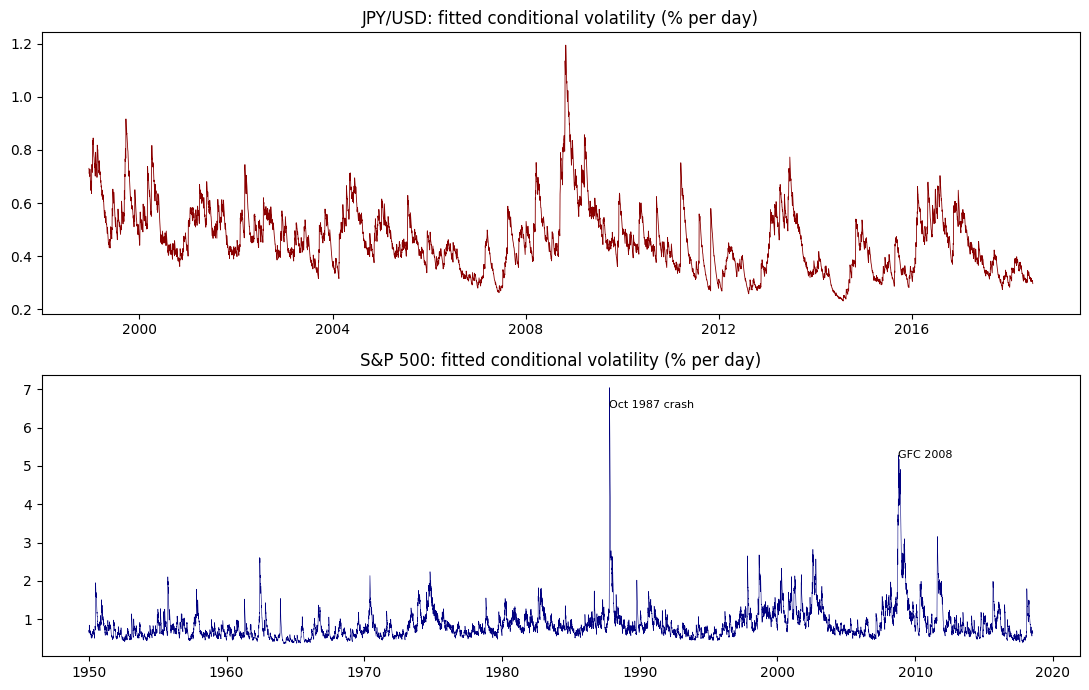

In [7]:
gsp = arch_model(rsp, vol='GARCH', p=1, q=1).fit(disp='off')
print(gsp.params.round(4))
print(f"S&P persistence = {gsp.params['alpha[1]'] + gsp.params['beta[1]']:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(11, 7))
axes[0].plot(gjpy.conditional_volatility, lw=0.6, color='darkred')
axes[0].set_title('JPY/USD: fitted conditional volatility (% per day)')
axes[0].annotate('1998 yen-carry unwind / LTCM', xy=(pd.Timestamp('1998-10-08'), 2.4), fontsize=8)
axes[0].annotate('GFC 2008-09', xy=(pd.Timestamp('2008-10-01'), 1.6), fontsize=8)

axes[1].plot(gsp.conditional_volatility, lw=0.4, color='navy')
axes[1].set_title('S&P 500: fitted conditional volatility (% per day)')
axes[1].annotate('Oct 1987 crash', xy=(pd.Timestamp('1987-10-19'), 6.5), fontsize=8)
axes[1].annotate('GFC 2008', xy=(pd.Timestamp('2008-10-01'), 5.2), fontsize=8)
plt.tight_layout(); plt.show()


**What to interpret.** The conditional volatility series *is* the model output a risk desk consumes daily. For the yen, vol spikes in October 1998 (the famous two-day 10%+ yen move), 2008–09 and the 2016 risk-off episodes. For the S&P, October 1987, 2008 and 2020-style episodes (sample ends 2018) dominate; calm regimes sit near 0.5% per day while crises exceed 5%. Equity volatility reacts harder to news ($\alpha \approx 0.09$ vs 0.035) — equity markets digest more firm-specific and leverage-driven shocks.

## Task 7 — Diagnostics on standardised residuals

In [8]:
z = gjpy.resid / gjpy.conditional_volatility

lm, lm_p, f, f_p = het_arch(z.dropna(), nlags=5)
print(f"ARCH-LM(5) on standardised residuals: LM = {lm:.2f}, p-value = {lm_p:.4f}")
print(f"kurtosis: raw rjpy = {rjpy.kurtosis():.2f}, standardised residuals = {z.kurtosis():.2f}")


ARCH-LM(5) on standardised residuals: LM = 31.08, p-value = 0.0000
kurtosis: raw rjpy = 4.64, standardised residuals = 4.36


**What to interpret.** The ARCH-LM statistic collapses from ≈179 on the raw returns to ≈31 on the standardised residuals — the GARCH recursion has absorbed the bulk of the volatility clustering. It still formally rejects, but beware the sample size: with $T\approx7{,}100$ even economically trivial residual effects are "statistically significant"; richer specifications (asymmetry terms, next week) mop up some of the remainder. More telling is the kurtosis: it falls only modestly (≈4.6 → ≈4.4). Yen tails are driven largely by one-off jump days (intervention, carry-trade unwinds) rather than by clustered variance, so conditional normality is untenable — the case for Student-t errors, which we estimate next week.

## Task 8 — Interpretation

Both markets tell the same qualitative story — persistence near 0.99 — but with different anatomy: the S&P has a larger news coefficient ($\alpha\approx0.09$ vs $0.035$) and smaller memory ($\beta\approx0.91$ vs $0.96$); equity vol jumps harder on impact, FX vol glides. Persistence of 0.99 implies a volatility half-life of roughly 2–3 months: after a crisis spike, risk stays elevated long after headlines fade, which is why VaR limits and option prices remain high for months post-crash. Fat tails largely survive standardisation because clustering explains *when* turbulent periods happen but not *how big* individual surprises are within them — the conditional distribution itself has heavy tails (jump-like yen moves especially). Hence the Week 8 agenda: asymmetric (GJR/EGARCH) variance equations and t-distributed shocks.